# AML — Visualizations

Standalone visualization notebook for the AML Risk Detection project.  
All data loading and cleaning is done via `src/preprocessing.py`.  
Models are trained inline to produce self-contained evaluation plots.

**Sections:**
1. Data Loading & Preparation
2. Dataset Overview
3. Transaction Amount Distributions
4. Time Series Patterns
5. Model Training (for evaluation plots)
6. Evaluation Curves
7. PCA Projection

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Make src/ importable from notebooks/
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    clean_czech,
    clean_ibm,
    engineer_features,
    harmonize,
    load_czech,
    load_ibm,
    parse_ibm_patterns,
    FEATURE_COLS,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_SEED = 42
print(f'Device: {DEVICE}')

Device: cpu


## 1. Data Loading & Preparation

In [2]:
# Load raw data via src/preprocessing.py
ibm_raw    = load_ibm()
czech_raw  = load_czech()

# Clean
ibm_clean   = clean_ibm(ibm_raw)
czech_clean = clean_czech(czech_raw)

# Harmonize into unified schema
merged = harmonize(ibm_clean, czech_clean)

print(f'Merged shape : {merged.shape[0]:,} rows × {merged.shape[1]} cols')
print(f'Sources      : {merged["source"].value_counts().to_dict()}')
merged.head(3)

Merged shape : 6,134,656 rows × 10 cols
Sources      : {'ibm': 5078336, 'czech': 1056320}


,amount,amount_received,timestamp,sender_id,receiver_id,_label,payment_type,currency_send,currency_recv,source
0,3697.34,3697.34,2022-09-01 00:20:00,10_8000EBD30,10_8000EBD30,0,Reinvestment,US Dollar,US Dollar,ibm
1,0.01,0.01,2022-09-01 00:20:00,3208_8000F4580,1_8000F5340,0,Cheque,US Dollar,US Dollar,ibm
2,14675.57,14675.57,2022-09-01 00:00:00,3209_8000F4670,3209_8000F4670,0,Reinvestment,US Dollar,US Dollar,ibm


In [3]:
# Convenience views used by all visualization cells
ibm_d = merged[merged['source'] == 'ibm'].copy()
cz_d  = merged[merged['source'] == 'czech'].copy()

print(f'IBM rows   : {len(ibm_d):,}  |  Laundering: {(ibm_d["_label"]==1).sum():,}')
print(f'Czech rows : {len(cz_d):,}  |  Default:    {(cz_d["_label"]==1).sum():,}')

IBM rows   : 5,078,336  |  Laundering: 5,177
Czech rows : 1,056,320  |  Default:    22,760


## 2. Dataset Overview

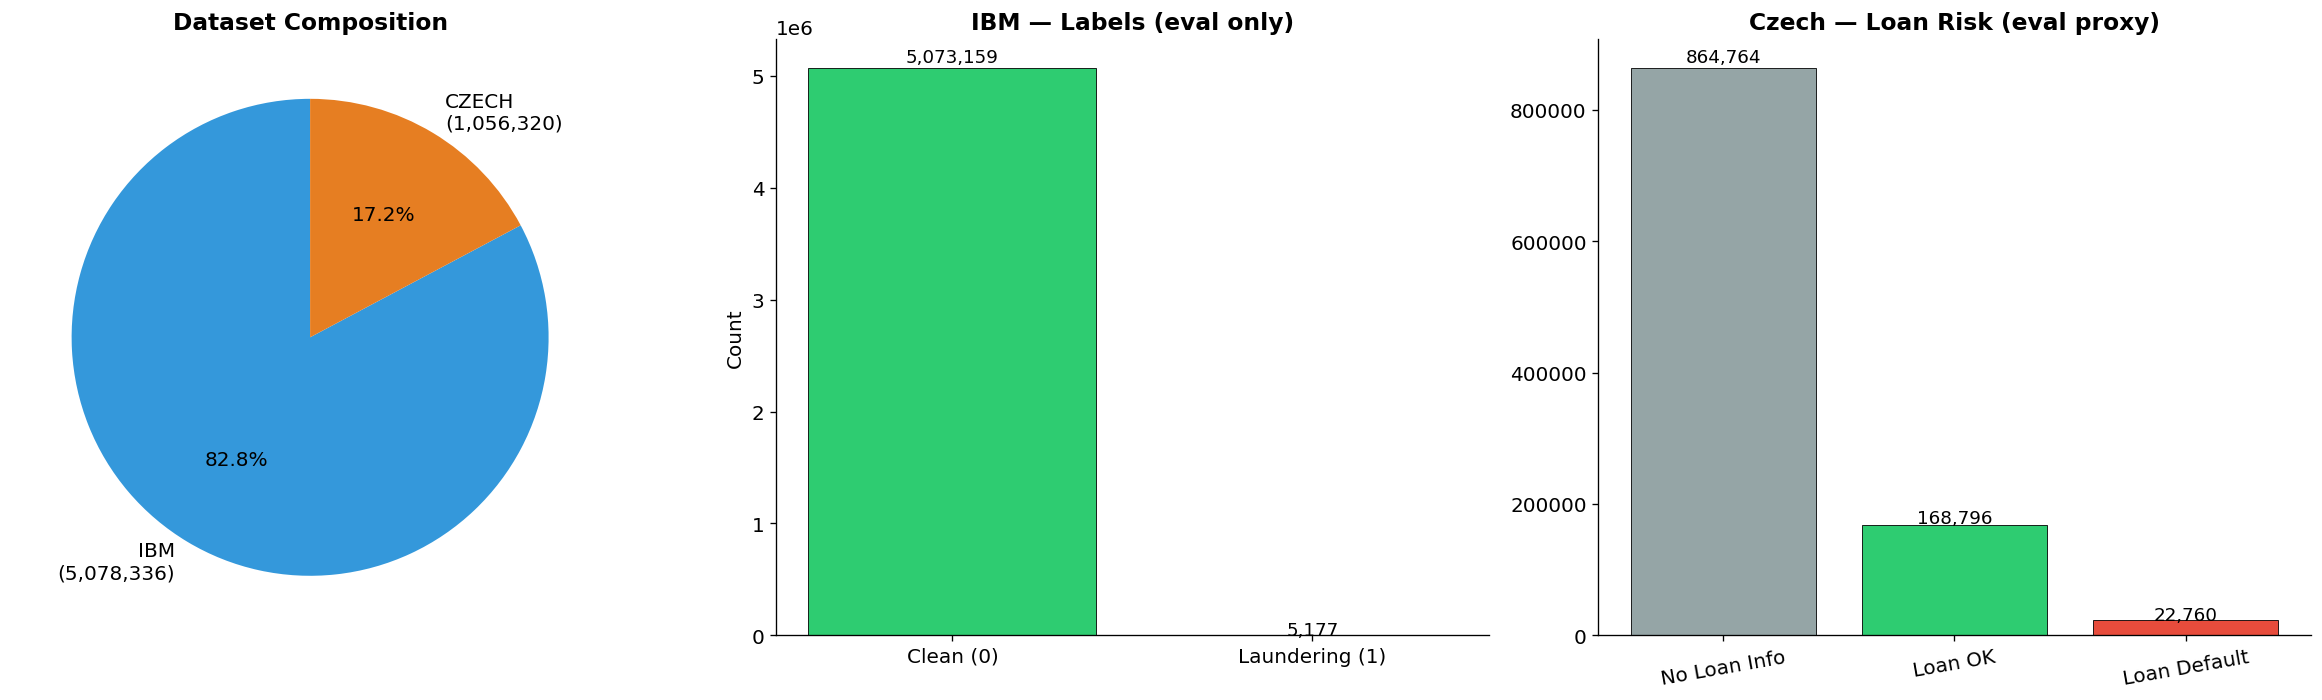

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Source split
ax = axes[0]
src = merged['source'].value_counts()
ax.pie(src.values, labels=[f"{k.upper()}\n({v:,})" for k,v in src.items()],
       colors=['#3498db','#e67e22'], autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
ax.set_title('Dataset Composition', fontsize=14, fontweight='bold')

# IBM target
ax = axes[1]
lbl = ibm_d['_label'].value_counts().sort_index()
bars = ax.bar(['Clean (0)','Laundering (1)'], lbl.values,
              color=['#2ecc71','#e74c3c'], edgecolor='black', linewidth=0.5)
for b,v in zip(bars, lbl.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01, f'{v:,}', ha='center', fontsize=11)
ax.set_title('IBM — Labels (eval only)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')

# Czech risk
ax = axes[2]
cl = cz_d['_label'].value_counts().sort_index()
nm = {-1:'No Loan Info', 0:'Loan OK', 1:'Loan Default'}
clr = {-1:'#95a5a6', 0:'#2ecc71', 1:'#e74c3c'}
bars = ax.bar([nm.get(k, str(k)) for k in cl.index], cl.values,
              color=[clr.get(k, '#aaa') for k in cl.index],
              edgecolor='black', linewidth=0.5)
for b,v in zip(bars, cl.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01, f'{v:,}', ha='center', fontsize=11)
ax.set_title('Czech — Loan Risk (eval proxy)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('viz1_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Transaction Amount Distributions

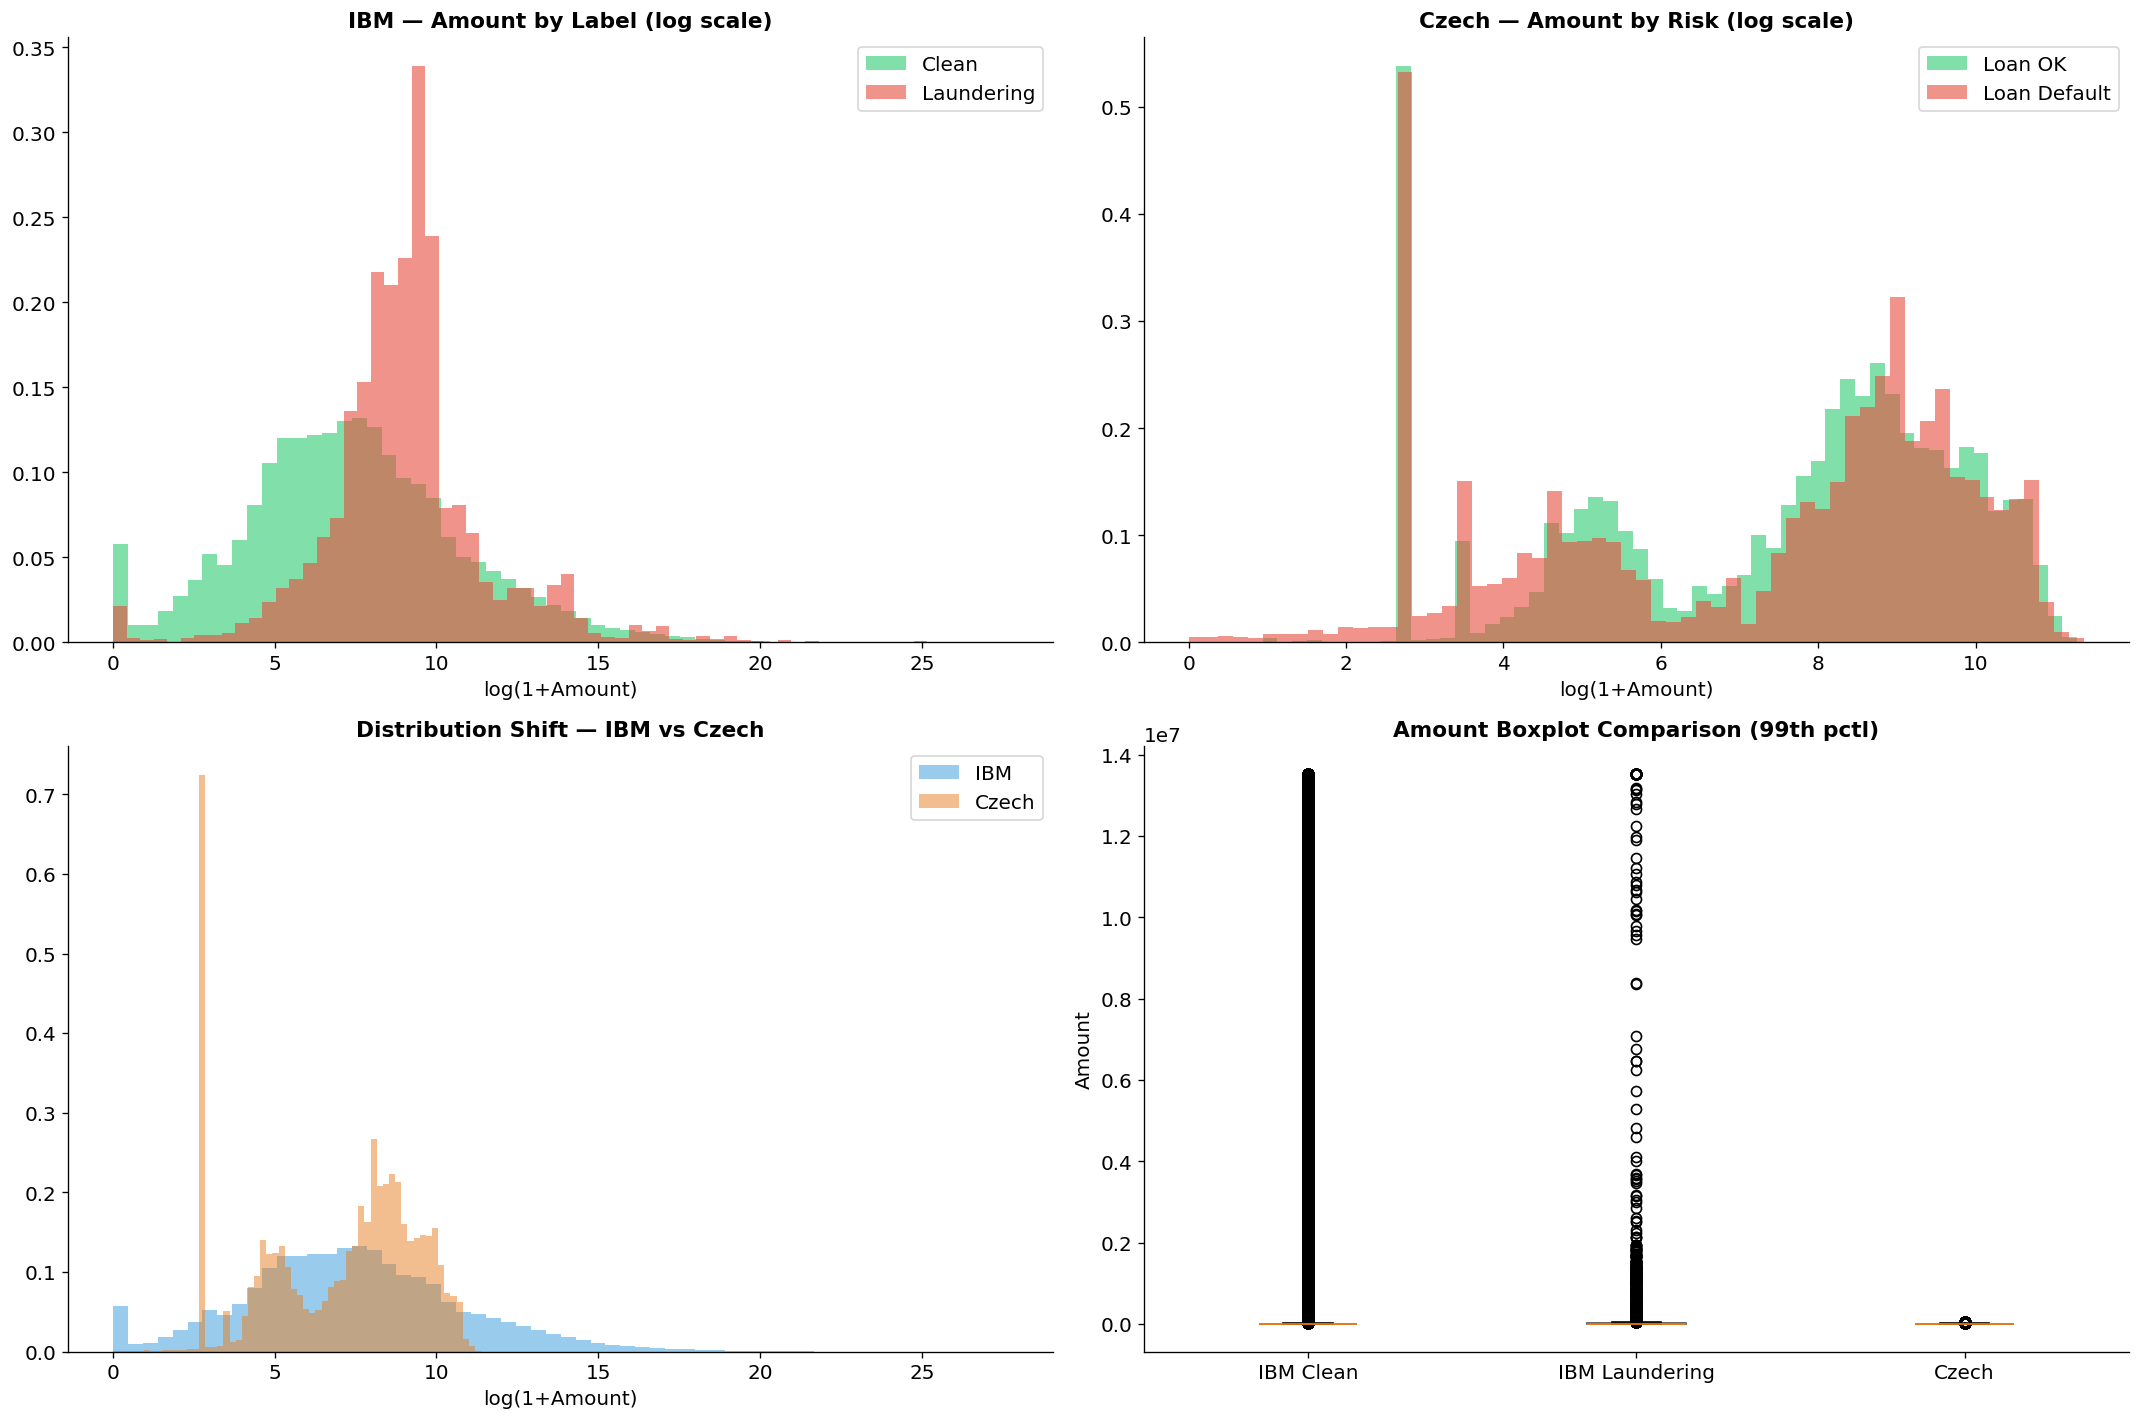

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# IBM clean vs laundering
ax = axes[0,0]
ax.hist(np.log1p(ibm_d[ibm_d['_label']==0]['amount']), bins=60, alpha=0.6, color='#2ecc71', label='Clean', density=True)
ax.hist(np.log1p(ibm_d[ibm_d['_label']==1]['amount']), bins=60, alpha=0.6, color='#e74c3c', label='Laundering', density=True)
ax.set_title('IBM — Amount by Label (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1+Amount)'); ax.legend()

# Czech by risk
ax = axes[0,1]
czl = cz_d[cz_d['_label'] >= 0]
if len(czl) > 0:
    ax.hist(np.log1p(czl[czl['_label']==0]['amount']), bins=60, alpha=0.6, color='#2ecc71', label='Loan OK', density=True)
    ax.hist(np.log1p(czl[czl['_label']==1]['amount']), bins=60, alpha=0.6, color='#e74c3c', label='Loan Default', density=True)
ax.set_title('Czech — Amount by Risk (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1+Amount)'); ax.legend()

# Distribution shift
ax = axes[1,0]
ax.hist(np.log1p(ibm_d['amount'].clip(lower=0)), bins=60, alpha=0.5, color='#3498db', label='IBM', density=True)
ax.hist(np.log1p(cz_d['amount'].clip(lower=0)),  bins=60, alpha=0.5, color='#e67e22', label='Czech', density=True)
ax.set_title('Distribution Shift — IBM vs Czech', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1+Amount)'); ax.legend()

# Box plot comparison
ax = axes[1,1]
data_bp = [
    ibm_d[ibm_d['_label']==0]['amount'].clip(upper=ibm_d['amount'].quantile(0.99)),
    ibm_d[ibm_d['_label']==1]['amount'].clip(upper=ibm_d['amount'].quantile(0.99)),
    cz_d['amount'].clip(upper=cz_d['amount'].quantile(0.99)),
]
bp = ax.boxplot(data_bp, labels=['IBM Clean','IBM Laundering','Czech'], patch_artist=True)
for p,c in zip(bp['boxes'], ['#2ecc71','#e74c3c','#e67e22']):
    p.set_facecolor(c); p.set_alpha(0.7)
ax.set_title('Amount Boxplot Comparison (99th pctl)', fontsize=13, fontweight='bold')
ax.set_ylabel('Amount')

plt.tight_layout()
plt.savefig('viz2_amounts.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Time Series Patterns

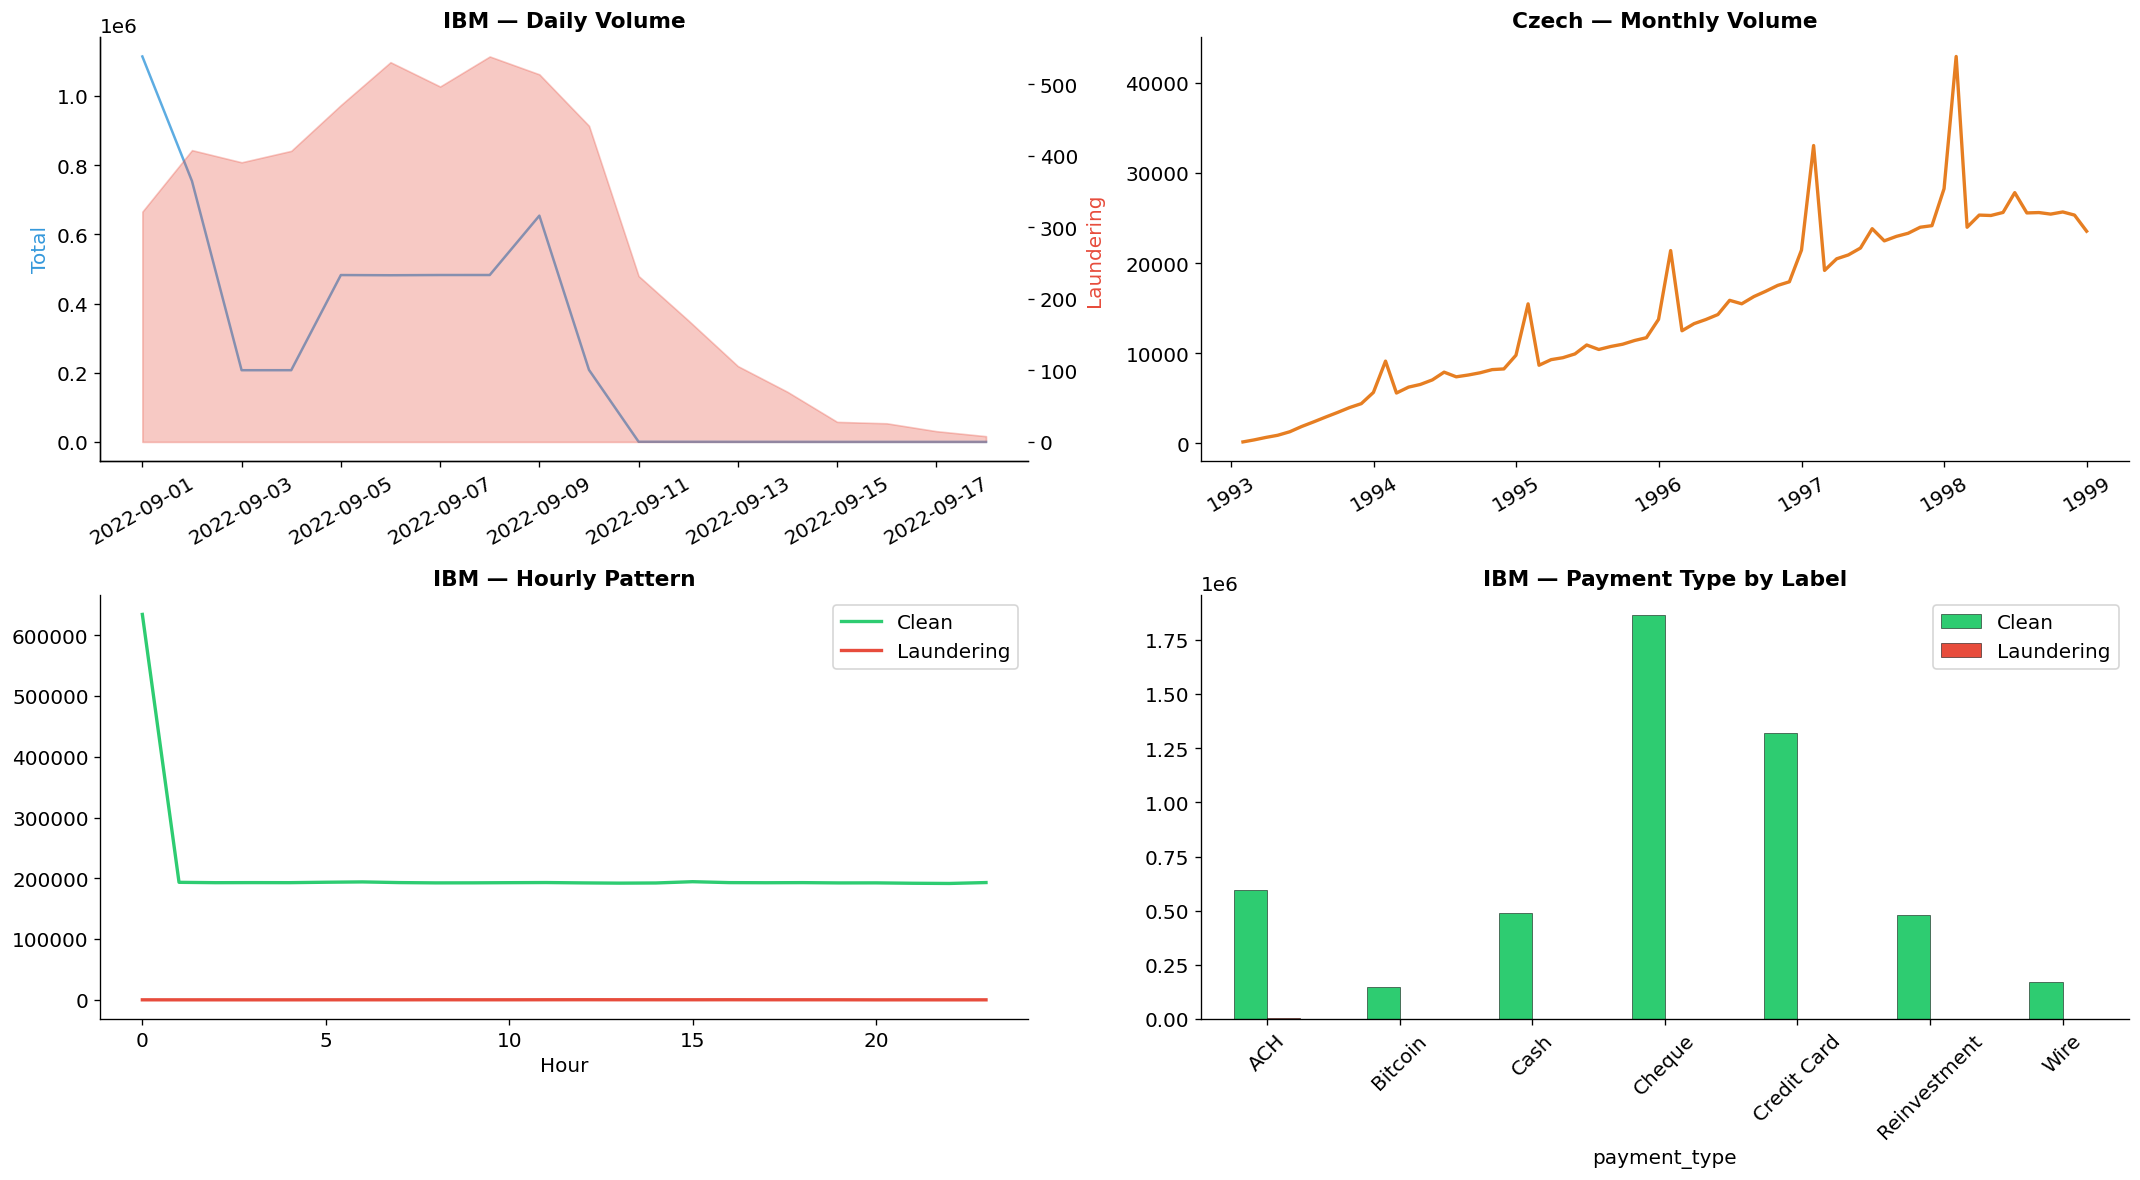

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# IBM daily volume
ax = axes[0,0]
ibm_daily = (ibm_d.set_index('timestamp')
               .resample('D')
               .agg(total=('amount','count'), launder=('_label','sum'))
               .dropna())
ax.plot(ibm_daily.index, ibm_daily['total'], color='#3498db', alpha=0.8)
ax2 = ax.twinx()
ax2.fill_between(ibm_daily.index, ibm_daily['launder'], color='#e74c3c', alpha=0.3)
ax.set_title('IBM — Daily Volume', fontsize=13, fontweight='bold')
ax.set_ylabel('Total', color='#3498db'); ax2.set_ylabel('Laundering', color='#e74c3c')
ax.tick_params(axis='x', rotation=30)

# Czech monthly volume
ax = axes[0,1]
cz_monthly = cz_d.dropna(subset=['timestamp']).set_index('timestamp').resample('M').size()
ax.plot(cz_monthly.index, cz_monthly.values, color='#e67e22', linewidth=2)
ax.set_title('Czech — Monthly Volume', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

# IBM hourly pattern
ax = axes[1,0]
ibm_hourly = ibm_d.groupby([ibm_d['timestamp'].dt.hour, '_label']).size().unstack(fill_value=0)
ibm_hourly.plot(ax=ax, color=['#2ecc71','#e74c3c'], linewidth=2)
ax.set_title('IBM — Hourly Pattern', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour'); ax.legend(['Clean','Laundering'])

# Payment types
ax = axes[1,1]
pt = ibm_d.groupby(['payment_type', '_label']).size().unstack(fill_value=0)
pt.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='black', linewidth=0.3)
ax.set_title('IBM — Payment Type by Label', fontsize=13, fontweight='bold')
ax.legend(['Clean','Laundering']); ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('viz3_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Training (for evaluation plots)

In [7]:
# Build feature matrix for IBM subset (has ground-truth labels)
patterns_df  = parse_ibm_patterns()
ibm_feat     = engineer_features(ibm_raw, patterns_df)

available    = [c for c in FEATURE_COLS if c in ibm_feat.columns]
X_ibm        = ibm_feat[available].values
y_ibm        = ibm_feat['Is Laundering']

scaler       = StandardScaler()
X_ibm_scaled = scaler.fit_transform(X_ibm)

print(f'Feature matrix : {X_ibm_scaled.shape}')
print(f'Fraud rate     : {y_ibm.mean()*100:.3f}%')

Feature matrix : (5078345, 14)
Fraud rate     : 0.102%


In [8]:
# Build IBM transaction graph (used for display; not used in features here)
G_ibm = nx.DiGraph()
sample = ibm_clean[['sender_id','receiver_id']].dropna().head(50_000)  # cap for speed
G_ibm.add_edges_from(zip(sample['sender_id'], sample['receiver_id']))
print(f'G_ibm: {G_ibm.number_of_nodes():,} nodes, {G_ibm.number_of_edges():,} edges')

G_ibm: 41,142 nodes, 40,163 edges


In [9]:
import time

# ── Isolation Forest ─────────────────────────────────────────────────────────
t0 = time.time()
iso = IsolationForest(n_estimators=300, contamination='auto', random_state=RANDOM_SEED, n_jobs=-1)
iso.fit(X_ibm_scaled)
iso_scores_ibm = -iso.decision_function(X_ibm_scaled)   # higher = more anomalous
print(f'Isolation Forest  {time.time()-t0:.1f}s')

# ── K-Means ───────────────────────────────────────────────────────────────────
t0 = time.time()
km = KMeans(n_clusters=10, random_state=RANDOM_SEED, n_init=10)
km.fit(X_ibm_scaled)
km_dists = np.min(km.transform(X_ibm_scaled), axis=1)
km_scores_ibm = (km_dists - km_dists.min()) / (km_dists.max() - km_dists.min() + 1e-9)
print(f'K-Means           {time.time()-t0:.1f}s')

# ── Autoencoder ───────────────────────────────────────────────────────────────
class _AE(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d,32), nn.ReLU(), nn.Linear(32,8), nn.ReLU())
        self.dec = nn.Sequential(nn.Linear(8,32), nn.ReLU(), nn.Linear(32,d))
    def forward(self, x):
        return self.dec(self.enc(x))

t0 = time.time()
ae = _AE(X_ibm_scaled.shape[1]).to(DEVICE)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
X_t = torch.tensor(X_ibm_scaled, dtype=torch.float32).to(DEVICE)
ae.train()
for _ in range(30):
    opt.zero_grad()
    loss = ((ae(X_t) - X_t) ** 2).mean()
    loss.backward()
    opt.step()
ae.eval()
with torch.no_grad():
    recon = ae(X_t).cpu().numpy()
ae_scores_ibm = np.mean((recon - X_ibm_scaled) ** 2, axis=1)
ae_scores_ibm = (ae_scores_ibm - ae_scores_ibm.min()) / (ae_scores_ibm.max() - ae_scores_ibm.min() + 1e-9)
print(f'Autoencoder       {time.time()-t0:.1f}s')

# ── Ensemble ──────────────────────────────────────────────────────────────────
def _norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
ens_scores_ibm = (_norm(iso_scores_ibm) + _norm(km_scores_ibm) + _norm(ae_scores_ibm)) / 3
print('Ensemble computed.')

Isolation Forest  30.2s
K-Means           21.6s
Autoencoder       89.5s
Ensemble computed.


## 6. Evaluation Curves

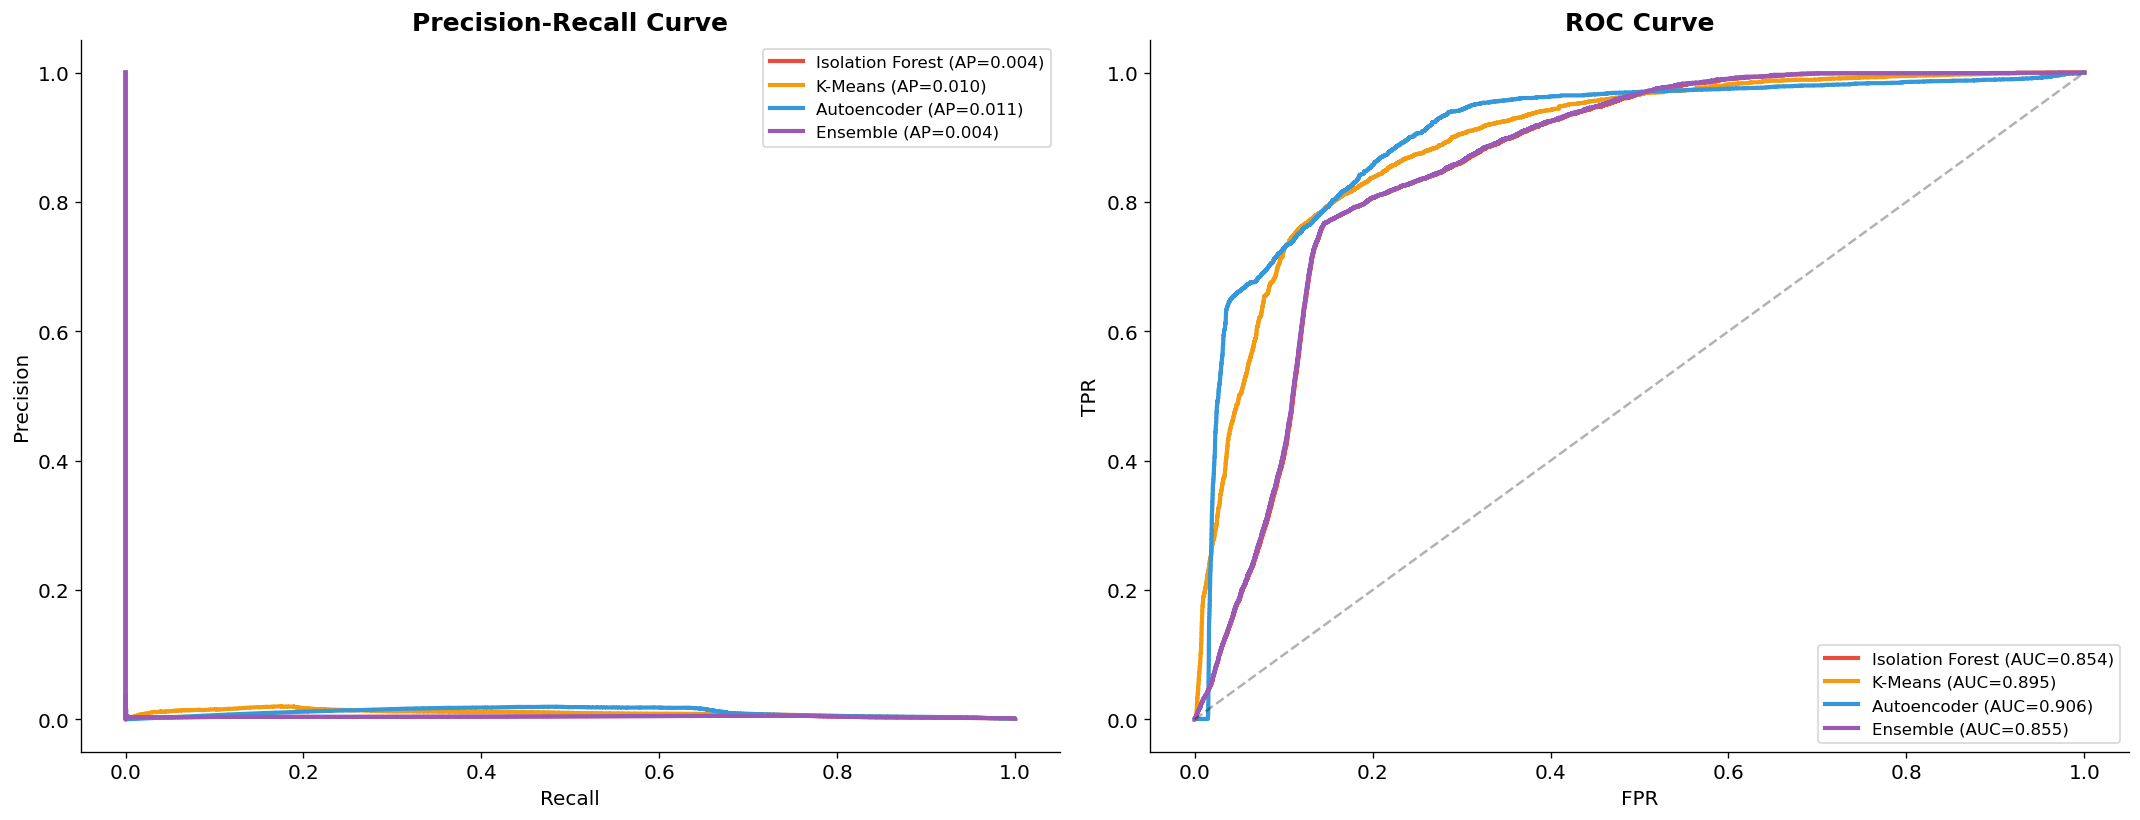

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

txn_models = {
    'Isolation Forest': (iso_scores_ibm, y_ibm),
    'K-Means':          (km_scores_ibm,  y_ibm),
    'Autoencoder':      (ae_scores_ibm,  y_ibm),
    'Ensemble':         (ens_scores_ibm, y_ibm),
}
cs = ['#e74c3c','#f39c12','#3498db','#9b59b6']

for ax_idx, (curve_fn, xlabel, ylabel, title) in enumerate([
    (precision_recall_curve, 'Recall',    'Precision', 'Precision-Recall'),
    (roc_curve,              'FPR',       'TPR',       'ROC'),
]):
    ax = axes[ax_idx]
    for (name, (scores, y_eval)), c in zip(txn_models.items(), cs):
        if curve_fn == precision_recall_curve:
            p, r, _ = curve_fn(y_eval, scores)
            ap = average_precision_score(y_eval, scores)
            ax.plot(r, p, color=c, linewidth=2.5, label=f'{name} (AP={ap:.3f})')
        else:
            fpr, tpr, _ = curve_fn(y_eval, scores)
            a = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=c, linewidth=2.5, label=f'{name} (AUC={a:.3f})')
    if curve_fn == roc_curve:
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
    ax.set_title(f'{title} Curve', fontsize=15, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('eval_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. PCA Projection

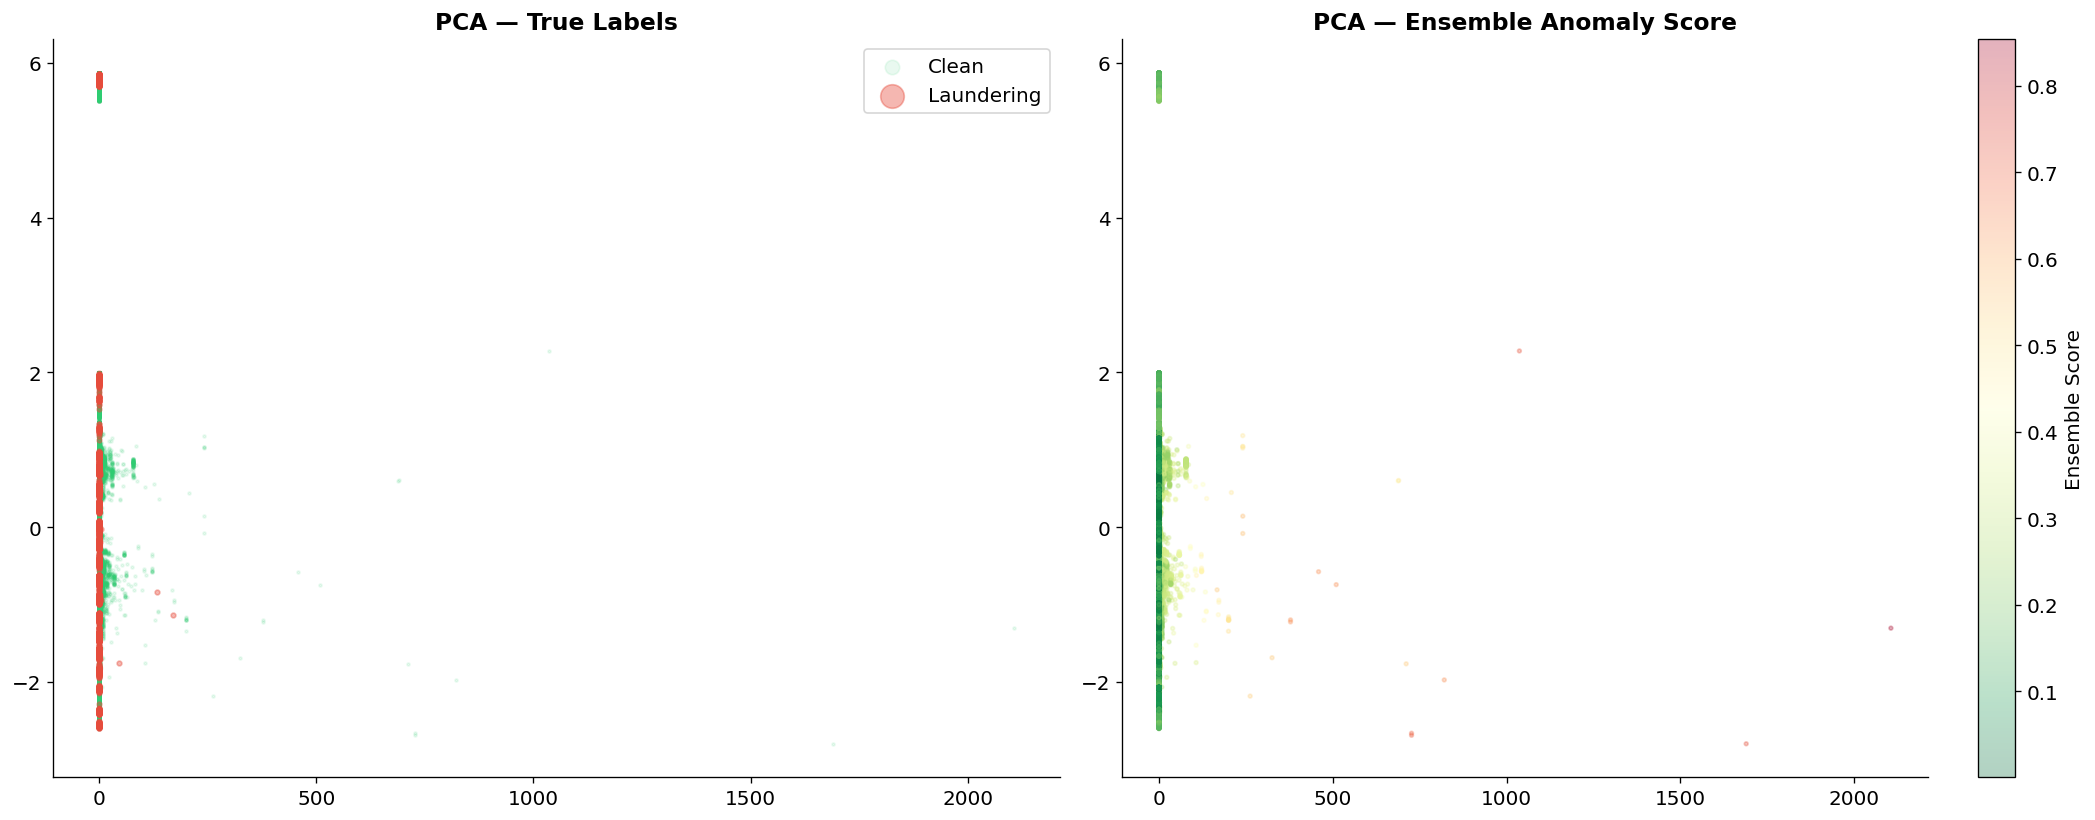

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

pca   = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_ibm_scaled)
y_arr = y_ibm.values

ax = axes[0]
ax.scatter(X_pca[y_arr==0, 0], X_pca[y_arr==0, 1], c='#2ecc71', alpha=0.1, s=3, label='Clean')
ax.scatter(X_pca[y_arr==1, 0], X_pca[y_arr==1, 1], c='#e74c3c', alpha=0.4, s=8, label='Laundering')
ax.set_title('PCA — True Labels', fontsize=14, fontweight='bold')
ax.legend(markerscale=5)

ax = axes[1]
sc = ax.scatter(X_pca[:,0], X_pca[:,1], c=ens_scores_ibm, cmap='RdYlGn_r', alpha=0.3, s=5)
plt.colorbar(sc, ax=ax, label='Ensemble Score')
ax.set_title('PCA — Ensemble Anomaly Score', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('pca_viz.png', dpi=150, bbox_inches='tight')
plt.show()